#### 00 - Dependencies

In [2]:
import os

os.environ["LLM_API_KEY"] = os.environ.get("LLM_API_KEY", "")
os.environ["LLM_BASE_URL"] = os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1")
os.environ["LLM_MODEL"] = os.environ.get("LLM_MODEL", "openai/gpt-4o-mini")
os.environ["LLM_TEMPERATURE"] = os.environ.get("LLM_TEMPERATURE", "0")

#### 1.0 - Data

- load
- split
- embed

In [1]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

url = "https://claude.com/blog/millennium-and-anthropic-are-building-a-digital-risk-analyst-with-claude"
classes = ["u-rich-text-blog u-margin-trim w-richtext"]
loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(class_=tuple(classes))),
)
docs = loader.load()
print(len(docs), "documents loaded from the web page")

/var/folders/2r/0xf5r35d0t1330pv9d7lrq1c0000gn/T/ipykernel_69045/1689528646.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


1 documents loaded from the web page


In [3]:
import langchain
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0,
    length_function=len,
)
splits = text_splitter.split_documents(docs)
print(len(splits), "splits created from the documents")

4 splits created from the documents


In [20]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = OpenAIEmbeddings(
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=embeddings)
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.8}
)


#### 2.0 - Retrieve and Generate

- prompt
- llm
- graph

In [24]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

prompt_template = """Answer the question based only on the following context:
{context}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(prompt_template)

llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)

In [25]:
from typing import Literal
from pydantic import BaseModel, Field

class RouteQuery(BaseModel):
    """Route a user query to the most relevant handler."""

    datasource: Literal["vectorstore", "general"] = Field(
        ...,
        description=(
            "Use 'vectorstore' for questions about 'Millennium and Anthropic are building a digital risk analyst with Claude' and 'general' "
            "for anything else."
        ),
    )

router_prompt_template = """Decide whether the user is asking about this new topic of anthropics about 'Millennium and Anthropic are building a digital risk analyst with Claude' or not. 
Only return vectorstore if it is and general otherwise.
"""
router_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", router_prompt_template),
            ("human", "{question}"),
        ]
    )

router_llm = llm.with_structured_output(RouteQuery)

In [26]:
graders_prompt_template = """No relative documents found for the given query. Review the query and rewrite it to be relevant to the topic of 'Millennium and Anthropic are building a digital risk analyst with Claude'."""
grader_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", graders_prompt_template),
        ("human", "{question}"),
    ]
)
grader_llm = ChatOpenAI(
    model=os.environ.get("LLM_MODEL", "openai/gpt-4o-mini"),
    temperature=float(os.environ.get("LLM_TEMPERATURE", "0")),
    api_key=os.environ.get("LLM_API_KEY", ""),
    base_url=os.environ.get("LLM_BASE_URL", "https://openrouter.ai/api/v1"),
)


In [48]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.documents import Document

RETRIEVE_RETRY_LIMIT = 3
class RAGState(TypedDict):   
    question: str
    route: str
    context: List[Document]
    retrieval_grader: str
    retrieve_retry: int
    answer: str

def route_question(state: RAGState) -> RAGState:
    messages = router_prompt.invoke({"question": state["question"]})
    decision: RouteQuery = router_llm.invoke(messages)
    return {"route": decision.datasource}

def general(state: RAGState) -> RAGState:
    messages = prompt.invoke({                  
        "context": "probably out of context or a general question.",
        "question": state["question"],
    })
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else response.content}

def retrieve(state: RAGState) -> RAGState:
    docs = retriever.invoke(state["question"])
    return {"context": docs}

def grade_retriever(state: RAGState) -> RAGState:
    retries = state.get("retrieve_retry", 0)
    if retries >= RETRIEVE_RETRY_LIMIT:
        return {"retrieval_grader": "dead_end"}

    if len(state["context"]) == 0:
        grade_messages = grader_prompt.invoke({"question": state["question"]})
        grade_response = grader_llm.invoke(grade_messages)
        rewritten = grade_response if isinstance(grade_response, str) else grade_response.content
        return {
            "retrieval_grader": "failed",
            "question": rewritten,
            "retrieve_retry": retries + 1,
        }

    return {"retrieval_grader": "passed"}
        
def generate(state: RAGState) -> RAGState:
    context_str = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"context": context_str, "question": state["question"]})
    response = llm.invoke(messages)
    return {"answer": response if isinstance(response, str) else response.content}            

def pick_ranchb(state: RAGState) -> Literal["retrieve", "general"]:
    return "retrieve" if state["route"] == "vectorstore" else "general"

def pick_retrieve_branch(state: RAGState) -> Literal["failed", "passed", "dead_end"]:
    return state["retrieval_grader"]


builder = StateGraph(RAGState)
builder.add_node("router", route_question)
builder.add_node("general", general)
builder.add_node("retrieve", retrieve)
builder.add_node("grade_retriever", grade_retriever)
builder.add_node("generate", generate)
builder.add_edge(START, "router")
builder.add_conditional_edges("router", pick_branch, {
    "retrieve": "retrieve",
    "general": "general",                       
})
builder.add_edge("retrieve", "grade_retriever")
builder.add_conditional_edges("grade_retriever", pick_retrieve_branch, {
    "failed": "retrieve",
    "passed": "generate",
    "dead_end": "general"
})
builder.add_edge("general", END)
builder.add_edge("generate", END)

graph = builder.compile()

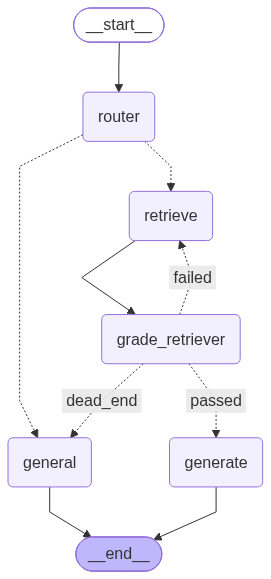

In [49]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [50]:
result = graph.invoke({"question": "What is Millennium and Anthropic building together?"})
result["answer"]

No relevant docs were retrieved using the relevance score threshold 0.8


'Yes, Millennium and Anthropic are collaborating to build a digital risk analyst powered by Claude, an advanced AI model developed by Anthropic. This digital risk analyst is designed to enhance risk assessment and management capabilities by leveraging AI technology to analyze data, identify potential risks, and provide insights for decision-making across different asset classes. It works alongside risk managers, helping to expedite and enrich the analysis of risk positions.'